# Frequency Collapse in SIREN Networks and Recovery via Weight Decomposition

This notebook demonstrates how **sine-activated MLPs (SIRENs)** suffer from **frequency collapse** during training — multiple hidden neurons lock onto similar frequencies, wasting network capacity — and how the weight decomposition $W_{\text{eff}} = W + \sum_i B_i C_i$ can break these degeneracies through the coupling matrix $P = I + \sum_i B_i B_i^\top$.

**The problem**: A SIREN's first hidden layer produces $\sin(\omega_0 \mathbf{w}_i \cdot t + b_i)$, where each neuron $i$ contributes a sinusoidal basis function at frequency $\omega_0 |\mathbf{w}_i|$. When the input $t$ spans a large range (many periods of these sinusoids), the loss landscape develops many local minima — small changes in frequency shift which period each data point lands in, making gradient-based frequency adjustment extremely difficult. Neurons get **locked** at their initial frequencies.

**Why decomposition helps**: The coupling matrix $P = I + \sum_i B_i B_i^\top$ introduces off-diagonal terms that mix gradients between neurons. This enables coordinated weight updates that can traverse the multi-period barriers in frequency space. Merge+resplit refreshes these coupling directions to break new degeneracies as training progresses.

**Protocol**:
1. **Target**: $N = 200$ positions on a multi-frequency curve in $\mathbb{R}^2$ (8 harmonics)
2. **Input**: raw integer positions $t \in \{0, 1, \ldots, N-1\}$ — first-layer activations span many sine periods, creating the multi-minima landscape
3. **Architecture**: 2-hidden-layer SIREN with width 16 (narrow — frequency allocation is a real bottleneck)
4. **Compare** across 20 random seeds:
   - **Baseline**: standard SIREN training
   - **Baseline + Split**: add low-rank factors, merge+resplit periodically
5. The decomposition breaks frequency lock-in, improving convergence reliability

In [1]:
import sys
sys.path.insert(0, "../src")

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy

from WeightDecomp import DecomposedLinear
from WeightDecomp.train_mnist import reset_factor_optimizer_state

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Sine-Activated MLP with DecomposedLinear

We build a SIREN directly from `DecomposedLinear` layers. The key architectural choice: the first layer multiplies by $\omega_0$ before the sine, controlling the initial frequency range. SIREN initialization ensures activations neither explode nor vanish through the sine nonlinearity.

For a single hidden layer, the output is:
$$\mathbf{y}(t) = W_2 \cdot \sin(\omega_0 W_1 t + \mathbf{b}_1) + \mathbf{b}_2$$

Each hidden neuron $i$ contributes a sinusoid at effective frequency $\omega_0 |W_{1,i}|$. With raw integer input $t \in \{0, \ldots, 199\}$, the sine argument $\omega_0 W_{1,i} \cdot t$ spans **hundreds of periods** for a typical weight. This means the loss landscape has many local minima per neuron — adjusting a frequency by even a small amount shifts which period each data point falls in, creating barriers to gradient-based optimization.

**Frequency collapse** occurs when neurons get locked at suboptimal frequencies and cannot escape.

In [2]:
class DecomposedSiren(nn.Module):
    """SIREN (Sinusoidal Representation Network) using DecomposedLinear layers.
    
    Architecture: scalar t -> hidden layers with sin activation -> R^d output.
    Uses DecomposedLinear so we can apply split/merge to break frequency degeneracies.
    """
    
    def __init__(self, layer_sizes, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.layers = nn.ModuleList()
        for i in range(len(layer_sizes) - 1):
            self.layers.append(DecomposedLinear(layer_sizes[i], layer_sizes[i + 1]))
        self._siren_init()
    
    def _siren_init(self):
        """SIREN-specific initialization (Sitzmann et al., 2020).
        
        First layer:  W ~ U(-1/n, 1/n)  (omega_0 applied in forward)
        Hidden layers: W ~ U(-sqrt(6/n)/omega_0, sqrt(6/n)/omega_0)
        
        DecomposedLinear stores the weight matrix as .W (not .weight).
        """
        for i, layer in enumerate(self.layers):
            n = layer.in_features
            with torch.no_grad():
                if i == 0:
                    layer.W.uniform_(-1.0 / n, 1.0 / n)
                else:
                    bound = np.sqrt(6.0 / n) / self.omega_0
                    layer.W.uniform_(-bound, bound)
                if layer.bias is not None:
                    layer.bias.uniform_(-1.0 / n, 1.0 / n)
    
    def forward(self, t):
        x = t
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            if i == 0:
                x = torch.sin(self.omega_0 * x)
            else:
                x = torch.sin(x)
        return self.layers[-1](x)
    
    def decomposed_layers(self):
        return list(self.layers)
    
    def split_all(self, ranks, rerandomize_B=True):
        for layer in self.layers:
            layer.split(ranks, rerandomize_B=rerandomize_B)
    
    def merge_all(self, rerandomize_B=True):
        for layer in self.layers:
            layer.merge(rerandomize_B=rerandomize_B)
    
    def first_layer_frequencies(self):
        """Extract effective frequencies from the first layer.
        
        Returns omega_0 * W_eff[:,0] — the effective frequency of each hidden neuron.
        Since input is 1D, each neuron has a single frequency.
        """
        w_eff = self.layers[0].effective_weight().detach()
        return (self.omega_0 * w_eff[:, 0]).cpu().numpy()

## Target Function and Training Utilities

We ask the network to learn $N = 200$ positions on a **multi-frequency curve** in $\mathbb{R}^2$:

$$f(t) = \sum_{k \in \{1,2,3,5,8,13,21,34\}} \frac{1}{k} \left(\cos\frac{2\pi k t}{N},\; \sin\frac{2\pi k t}{N}\right)$$

This is a superposition of **8 harmonics** at Fibonacci-spaced frequencies (avoiding integer-ratio relationships that would make the problem artificially easy). The network must allocate its 16 hidden neurons across these 8 frequency bands — with only 2 neurons per harmonic on average, there is zero room for redundancy.

**Crucially, we feed raw integer positions** $t \in \{0, 1, \ldots, 199\}$ as input. With $\omega_0 = 30$ and SIREN init $W_1 \sim U(-1, 1)$, the first-layer argument $\omega_0 W_{1,i} \cdot t$ can reach $\pm 6000$, spanning **$\sim 1000$ periods** of the sine. This is what creates the multi-minima landscape that traps neurons at wrong frequencies.

First-layer init frequencies (omega_0 * w): [ 26.23  23.24  -6.88 -10.53  24.63  16.81 -18.05  26.97  14.49  16.35
 -18.8    8.61 -10.52  23.44  -5.4   11.68]
Max sine argument per neuron: freq * 199 = [5220. 4625. 1369. 2095. 4902. 3345. 3593. 5367. 2884. 3254. 3742. 1713.
 2093. 4665. 1074. 2324.]
Periods spanned: [830.8 736.1 217.8 333.4 780.1 532.4 571.8 854.2 459.1 518.  595.5 272.6
 333.1 742.4 171.  369.9]

Input range: [0, 199]
Target harmonics: k = [1, 2, 3, 5, 8, 13, 21, 34]
Target freqs (2πk/N): ['0.0314', '0.0628', '0.0942', '0.1571', '0.2513', '0.4084', '0.6597', '1.0681']


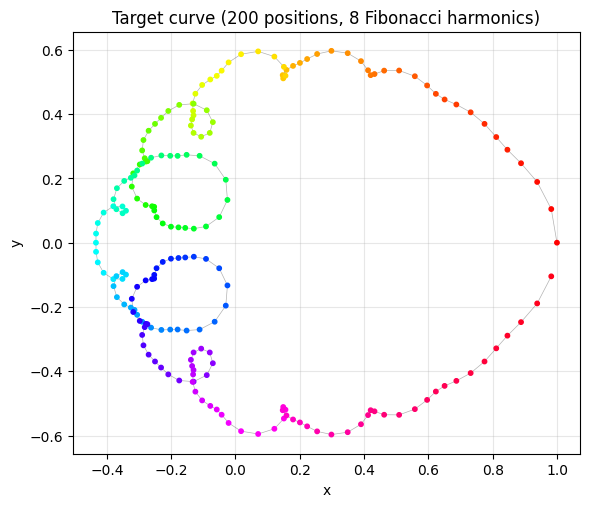

In [3]:
N_POSITIONS = 200
HARMONICS = [(k, 1.0 / k) for k in [1, 2, 3, 5, 8, 13, 21, 34]]  # Fibonacci-spaced

def make_target(N=N_POSITIONS, harmonics=HARMONICS):
    """Generate target positions: sum of sinusoidal harmonics in R^2.
    
    Returns raw integer inputs (NOT normalized) to force the SIREN
    through many sine periods, creating the multi-minima landscape.
    """
    t = torch.arange(N, dtype=torch.float32)
    x = torch.zeros(N)
    y = torch.zeros(N)
    for k, amp in harmonics:
        phase = 2 * np.pi * k * t / N
        x += amp * torch.cos(phase)
        y += amp * torch.sin(phase)
    # Normalize to roughly unit scale
    scale = torch.sqrt(x**2 + y**2).max()
    x, y = x / scale, y / scale
    targets = torch.stack([x, y], dim=1)  # (N, 2)
    inputs = t.unsqueeze(1)                # (N, 1), RAW integers
    return inputs, targets

inputs, targets = make_target()
inputs, targets = inputs.to(device), targets.to(device)

# Sanity check: how many sine periods does a typical neuron span?
torch.manual_seed(0)
_demo = DecomposedSiren([1, 16, 16, 2], omega_0=30.0)
_freqs = _demo.first_layer_frequencies()
_max_t = N_POSITIONS - 1
print(f"First-layer init frequencies (omega_0 * w): {_freqs.round(2)}")
print(f"Max sine argument per neuron: freq * {_max_t} = {(np.abs(_freqs) * _max_t).round(0)}")
print(f"Periods spanned: {(np.abs(_freqs) * _max_t / (2*np.pi)).round(1)}")
del _demo

print(f"\nInput range: [{inputs.min().item():.0f}, {inputs.max().item():.0f}]")
print(f"Target harmonics: k = {[k for k, _ in HARMONICS]}")
print(f"Target freqs (2πk/N): {[f'{2*np.pi*k/N_POSITIONS:.4f}' for k, _ in HARMONICS]}")

# Visualize the target curve
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
t_np = targets.cpu().numpy()
ax.plot(t_np[:, 0], t_np[:, 1], "k-", linewidth=0.5, alpha=0.3)
ax.scatter(t_np[:, 0], t_np[:, 1], c=np.arange(N_POSITIONS), cmap="hsv", s=10, zorder=5)
ax.set_aspect("equal")
ax.set_title(f"Target curve ({N_POSITIONS} positions, {len(HARMONICS)} Fibonacci harmonics)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
def train_siren(model, inputs, targets, epochs, lr=5e-4, log_every=1000):
    """Train a SIREN on the position-fitting task. Returns per-epoch losses."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    for epoch in range(1, epochs + 1):
        pred = model(inputs)
        loss = criterion(pred, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if log_every and epoch % log_every == 0:
            print(f"    Epoch {epoch:4d}/{epochs} | MSE: {loss.item():.6f}")
    return losses, optimizer


def train_siren_with_splits(model, inputs, targets, epochs, ranks, merge_every,
                            lr=5e-4, log_every=1000):
    """Train a SIREN with periodic merge+resplit. Returns per-epoch losses."""
    model.split_all(ranks)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    for epoch in range(1, epochs + 1):
        if epoch > 1 and (epoch - 1) % merge_every == 0:
            model.merge_all(rerandomize_B=True)
            reset_factor_optimizer_state(optimizer, model)
            # if log_every:
            #     print(f"    [Merge+resplit at epoch {epoch}]")
        pred = model(inputs)
        loss = criterion(pred, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if log_every and epoch % log_every == 0:
            print(f"    Epoch {epoch:4d}/{epochs} | MSE: {loss.item():.6f}")
    return losses


def frequency_spread(model):
    """Measure how well-spread the first-layer frequencies are.
    
    Returns the standard deviation of effective frequencies — higher means
    neurons are using diverse frequencies (good), lower means collapse (bad).
    """
    freqs = model.first_layer_frequencies()
    return np.std(np.abs(freqs))


def reconstruction_error(model, inputs, targets):
    """Per-position L2 error between prediction and target."""
    with torch.no_grad():
        pred = model(inputs)
        err = (pred - targets).pow(2).sum(dim=1).sqrt()
    return err.cpu().numpy()

## Multi-Seed Experiment

We run 20 random seeds. For each seed, both the baseline and split models start from the **same initialization** (deep copy), so any difference is purely due to optimization geometry.

- **Baseline**: train 2000 epochs with Adam
- **Baseline + Split**: same, but add factors (ranks $[4]$) and merge+resplit every 400 epochs

With width 16 and 8 target harmonics, the network is capacity-starved. With raw integer input spanning ~1000 sine periods per neuron, the loss landscape is riddled with local minima. This is where frequency lock-in becomes the dominant failure mode.

A run "succeeds" if final MSE $< 0.01$.

In [5]:
N_SEEDS = 5
EPOCHS = 2000
LR = 1e-3
LAYER_SIZES = [1, 16, 16, 16, 16, 16, 16, 2]
OMEGA_0 = 1.0
RANKS = [4, 4, 4, 4]
MERGE_EVERY = 500

results_baseline = []
results_split = []

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    
    # Create base model
    base = DecomposedSiren(LAYER_SIZES, omega_0=OMEGA_0).to(device)
    
    # --- Baseline ---
    print(f"--- Seed {seed:2d}/{N_SEEDS}: Baseline ---")
    model_bl = copy.deepcopy(base)
    losses_bl, _ = train_siren(model_bl, inputs, targets, EPOCHS, lr=LR)
    results_baseline.append({
        "seed": seed,
        "losses": losses_bl,
        "final_mse": losses_bl[-1],
        "freq_spread": frequency_spread(model_bl),
        "freqs": model_bl.first_layer_frequencies(),
        "model": model_bl,
    })
    
    # --- Baseline + Split ---
    print(f"--- Seed {seed:2d}/{N_SEEDS}: Baseline + Split ---")
    model_sp = copy.deepcopy(base)
    losses_sp = train_siren_with_splits(
        model_sp, inputs, targets, EPOCHS, RANKS, MERGE_EVERY, lr=LR
    )
    results_split.append({
        "seed": seed,
        "losses": losses_sp,
        "final_mse": losses_sp[-1],
        "freq_spread": frequency_spread(model_sp),
        "freqs": model_sp.first_layer_frequencies(),
        "model": model_sp,
    })

# Summary
SUCCESS_THRESH = 0.01
bl_success = sum(1 for r in results_baseline if r["final_mse"] < SUCCESS_THRESH)
sp_success = sum(1 for r in results_split if r["final_mse"] < SUCCESS_THRESH)
print(f"\n{'='*60}")
print(f"Success rate (MSE < {SUCCESS_THRESH}):")
print(f"  Baseline:        {bl_success}/{N_SEEDS} ({100*bl_success/N_SEEDS:.0f}%)")
print(f"  Baseline + Split: {sp_success}/{N_SEEDS} ({100*sp_success/N_SEEDS:.0f}%)")
print(f"\nMedian final MSE:")
print(f"  Baseline:        {np.median([r['final_mse'] for r in results_baseline]):.6f}")
print(f"  Baseline + Split: {np.median([r['final_mse'] for r in results_split]):.6f}")

--- Seed  0/5: Baseline ---
    Epoch 1000/2000 | MSE: 0.000160
    Epoch 2000/2000 | MSE: 0.000003
--- Seed  0/5: Baseline + Split ---
    Epoch 1000/2000 | MSE: 0.000007
    Epoch 2000/2000 | MSE: 0.000000
--- Seed  1/5: Baseline ---
    Epoch 1000/2000 | MSE: 0.000424
    Epoch 2000/2000 | MSE: 0.000009
--- Seed  1/5: Baseline + Split ---
    Epoch 1000/2000 | MSE: 0.000008
    Epoch 2000/2000 | MSE: 0.000000
--- Seed  2/5: Baseline ---
    Epoch 1000/2000 | MSE: 0.000030
    Epoch 2000/2000 | MSE: 0.000090
--- Seed  2/5: Baseline + Split ---
    Epoch 1000/2000 | MSE: 0.000406
    Epoch 2000/2000 | MSE: 0.000000
--- Seed  3/5: Baseline ---
    Epoch 1000/2000 | MSE: 0.000067
    Epoch 2000/2000 | MSE: 0.000037
--- Seed  3/5: Baseline + Split ---
    Epoch 1000/2000 | MSE: 0.000021
    Epoch 2000/2000 | MSE: 0.000000
--- Seed  4/5: Baseline ---
    Epoch 1000/2000 | MSE: 0.000153
    Epoch 2000/2000 | MSE: 0.000031
--- Seed  4/5: Baseline + Split ---
    Epoch 1000/2000 | MSE: 0.000

## Results: Aggregate Comparison

/tmp/ipykernel_3308366/544532387.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


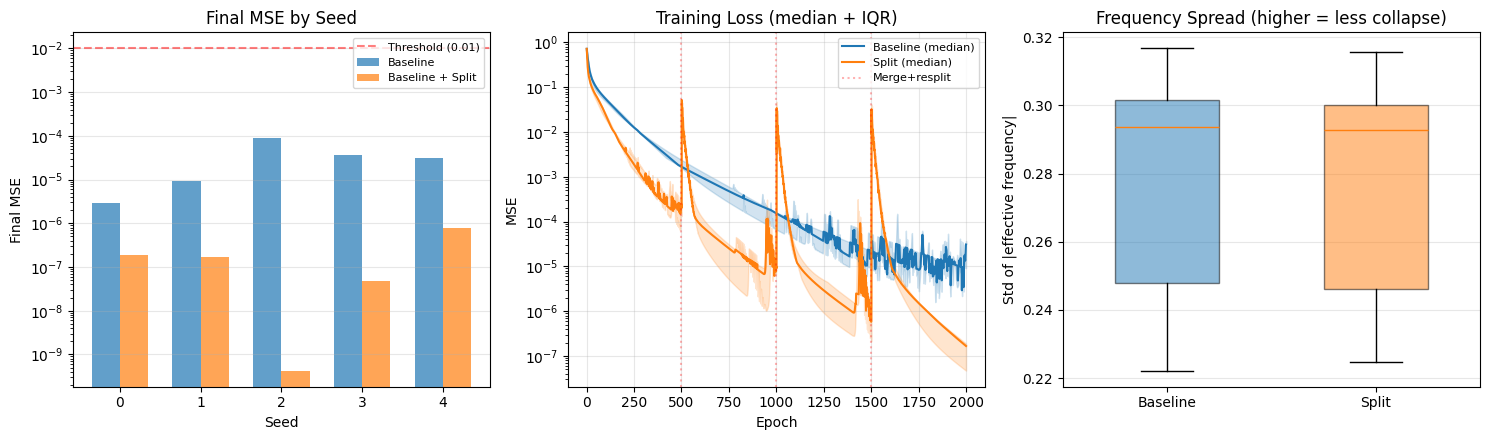

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Panel 1: Final MSE per seed ---
ax = axes[0]
seeds = np.arange(N_SEEDS)
bl_mses = [r["final_mse"] for r in results_baseline]
sp_mses = [r["final_mse"] for r in results_split]
width = 0.35
ax.bar(seeds - width/2, bl_mses, width, label="Baseline", color="tab:blue", alpha=0.7)
ax.bar(seeds + width/2, sp_mses, width, label="Baseline + Split", color="tab:orange", alpha=0.7)
ax.axhline(y=SUCCESS_THRESH, color="red", linestyle="--", alpha=0.5, label=f"Threshold ({SUCCESS_THRESH})")
ax.set_xlabel("Seed")
ax.set_ylabel("Final MSE")
ax.set_title("Final MSE by Seed")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# --- Panel 2: Loss curves (median + IQR) ---
ax = axes[1]
bl_all = np.array([r["losses"] for r in results_baseline])
sp_all = np.array([r["losses"] for r in results_split])
epochs = np.arange(1, EPOCHS + 1)

for data, label, color in [(bl_all, "Baseline", "tab:blue"), (sp_all, "Split", "tab:orange")]:
    median = np.median(data, axis=0)
    q25 = np.percentile(data, 25, axis=0)
    q75 = np.percentile(data, 75, axis=0)
    ax.plot(epochs, median, label=f"{label} (median)", color=color)
    ax.fill_between(epochs, q25, q75, alpha=0.2, color=color)

for me in range(MERGE_EVERY, EPOCHS, MERGE_EVERY):
    ax.axvline(x=me, color="red", linestyle=":", alpha=0.3,
               label="Merge+resplit" if me == MERGE_EVERY else None)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Training Loss (median + IQR)")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Panel 3: Frequency spread ---
ax = axes[2]
bl_spreads = [r["freq_spread"] for r in results_baseline]
sp_spreads = [r["freq_spread"] for r in results_split]
bp = ax.boxplot(
    [bl_spreads, sp_spreads],
    labels=["Baseline", "Split"],
    patch_artist=True,
    widths=0.5,
)
bp["boxes"][0].set_facecolor("tab:blue")
bp["boxes"][0].set_alpha(0.5)
bp["boxes"][1].set_facecolor("tab:orange")
bp["boxes"][1].set_alpha(0.5)
ax.set_ylabel("Std of |effective frequency|")
ax.set_title("Frequency Spread (higher = less collapse)")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("siren_frequency_collapse_aggregate.png", dpi=150, bbox_inches="tight")
plt.show()

## Case Study: Learned Curves and Frequency Spectra

We pick the seed where the baseline has the **worst** final MSE (deepest frequency collapse) and compare its learned curve and frequency spectrum against the split model from the same seed.

Case study seed: 2
  Baseline MSE:  0.000090
  Split MSE:     0.000000


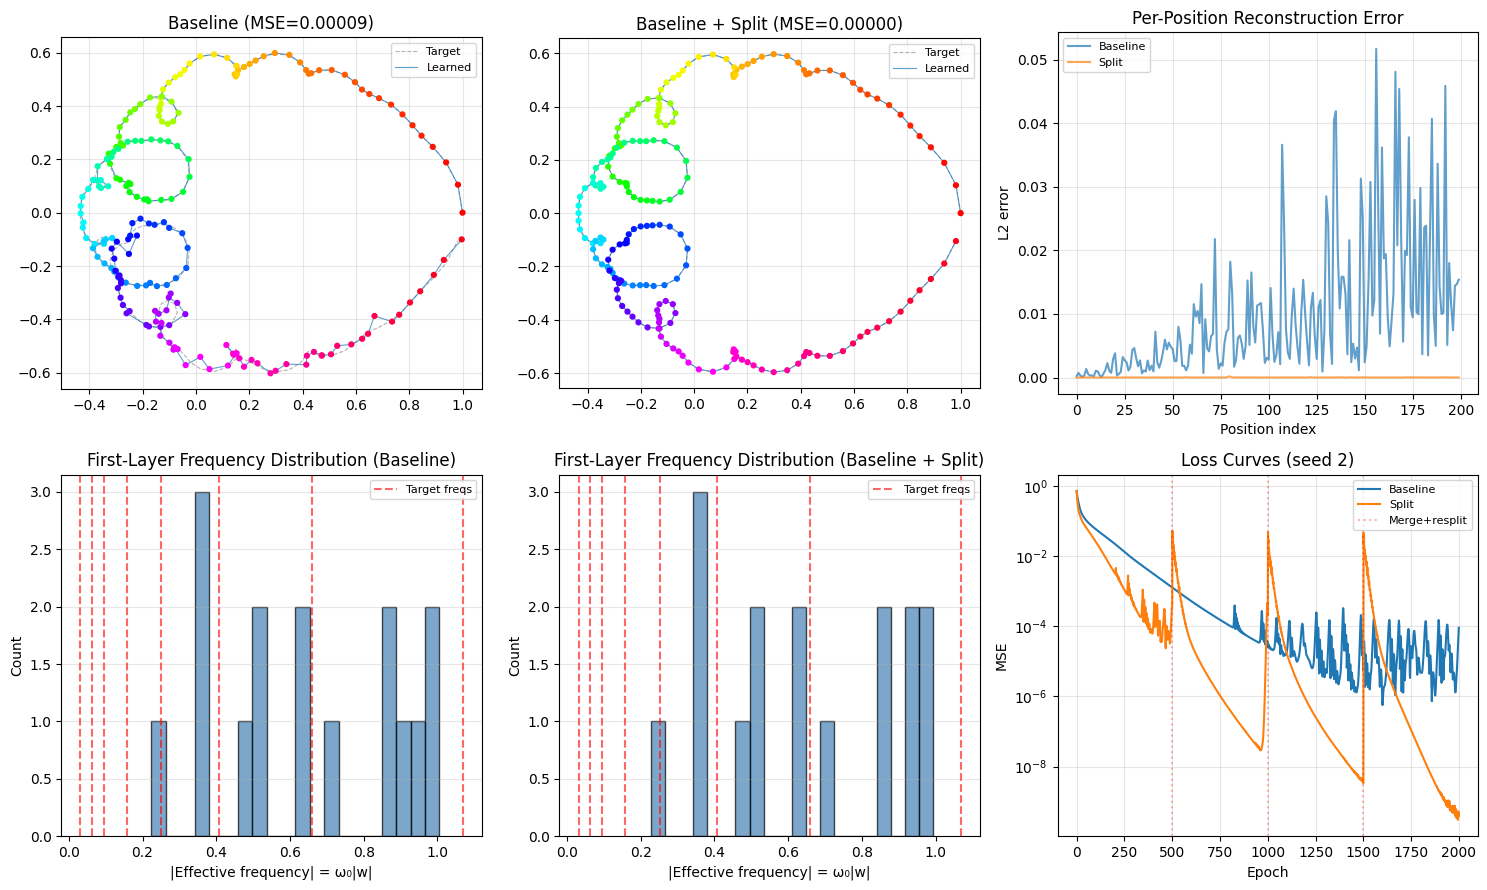

In [7]:
# Find worst baseline seed
worst_idx = max(range(N_SEEDS), key=lambda i: results_baseline[i]["final_mse"])
best_bl = results_baseline[worst_idx]
best_sp = results_split[worst_idx]
print(f"Case study seed: {worst_idx}")
print(f"  Baseline MSE:  {best_bl['final_mse']:.6f}")
print(f"  Split MSE:     {best_sp['final_mse']:.6f}")

# Evaluate at training positions only (raw integers) — interpolation between
# integer positions is meaningless for high-frequency SIRENs
with torch.no_grad():
    pred_bl = best_bl["model"](inputs).cpu().numpy()
    pred_sp = best_sp["model"](inputs).cpu().numpy()

target_np = targets.cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# --- Row 1: Learned curves ---
for ax, pred, name, mse in [
    (axes[0, 0], pred_bl, "Baseline", best_bl["final_mse"]),
    (axes[0, 1], pred_sp, "Baseline + Split", best_sp["final_mse"]),
]:
    # Connect consecutive training positions with lines
    ax.plot(target_np[:, 0], target_np[:, 1], "k--", alpha=0.3, label="Target", linewidth=0.8)
    ax.plot(pred[:, 0], pred[:, 1], "-", linewidth=0.8, label="Learned", alpha=0.7)
    ax.scatter(pred[:, 0], pred[:, 1], c=np.arange(N_POSITIONS), cmap="hsv", s=12, zorder=5)
    ax.set_aspect("equal")
    ax.set_title(f"{name} (MSE={mse:.5f})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# --- Row 1, Col 3: Per-position error ---
ax = axes[0, 2]
err_bl = reconstruction_error(best_bl["model"], inputs, targets)
err_sp = reconstruction_error(best_sp["model"], inputs, targets)
ax.plot(np.arange(N_POSITIONS), err_bl, label="Baseline", color="tab:blue", alpha=0.7)
ax.plot(np.arange(N_POSITIONS), err_sp, label="Split", color="tab:orange", alpha=0.7)
ax.set_xlabel("Position index")
ax.set_ylabel("L2 error")
ax.set_title("Per-Position Reconstruction Error")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Row 2: Frequency spectra ---
target_freqs = [2 * np.pi * k / N_POSITIONS for k, _ in HARMONICS]

for ax, result, name in [
    (axes[1, 0], best_bl, "Baseline"),
    (axes[1, 1], best_sp, "Baseline + Split"),
]:
    freqs = result["freqs"]
    ax.hist(np.abs(freqs), bins=20, color="steelblue", alpha=0.7, edgecolor="black")
    for i, tf in enumerate(target_freqs):
        ax.axvline(x=tf, color="red", linestyle="--", alpha=0.6,
                   label="Target freqs" if i == 0 else None)
    ax.set_xlabel("|Effective frequency| = ω₀|w|")
    ax.set_ylabel("Count")
    ax.set_title(f"First-Layer Frequency Distribution ({name})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

# --- Row 2, Col 3: Loss curves for this seed ---
ax = axes[1, 2]
ax.plot(best_bl["losses"], label="Baseline", color="tab:blue")
ax.plot(best_sp["losses"], label="Split", color="tab:orange")
for me in range(MERGE_EVERY, EPOCHS, MERGE_EVERY):
    ax.axvline(x=me, color="red", linestyle=":", alpha=0.3,
               label="Merge+resplit" if me == MERGE_EVERY else None)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title(f"Loss Curves (seed {worst_idx})")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("siren_frequency_collapse_case_study.png", dpi=150, bbox_inches="tight")
plt.show()

## Frequency Evolution During Training

To see the coupling matrix in action, we retrain the worst-seed pair and snapshot the first-layer frequency distribution at several checkpoints. In the baseline, neurons that start at similar frequencies stay clustered. In the split model, merge+resplit events visibly redistribute frequencies.

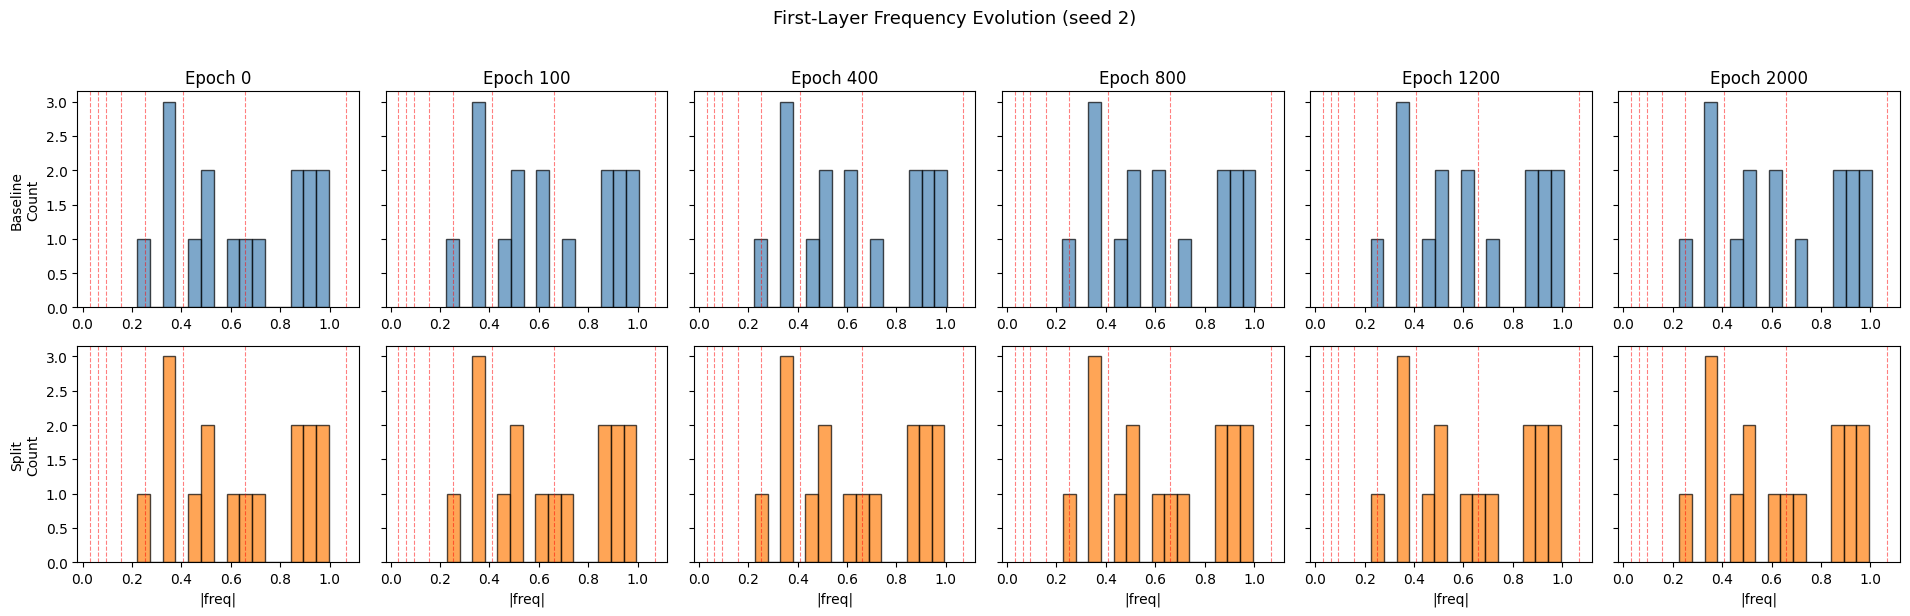

In [8]:
SNAPSHOT_EPOCHS = [0, 100, 400, 800, 1200, 2000]

def train_with_snapshots(model, inputs, targets, epochs, lr, snapshot_at,
                         ranks=None, merge_every=None):
    """Train and record frequency snapshots at specified epochs."""
    if ranks:
        model.split_all(ranks)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    snapshots = {}
    
    if 0 in snapshot_at:
        snapshots[0] = model.first_layer_frequencies().copy()
    
    for epoch in range(1, epochs + 1):
        if (ranks and merge_every
                and epoch > 1 and (epoch - 1) % merge_every == 0):
            model.merge_all(rerandomize_B=True)
            reset_factor_optimizer_state(optimizer, model)
        
        pred = model(inputs)
        loss = criterion(pred, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if epoch in snapshot_at:
            snapshots[epoch] = model.first_layer_frequencies().copy()
    
    return snapshots

# Retrain worst seed with snapshots
torch.manual_seed(worst_idx)
base = DecomposedSiren(LAYER_SIZES, omega_0=OMEGA_0).to(device)

model_bl_snap = copy.deepcopy(base)
snaps_bl = train_with_snapshots(
    model_bl_snap, inputs, targets, EPOCHS, LR, SNAPSHOT_EPOCHS
)

model_sp_snap = copy.deepcopy(base)
snaps_sp = train_with_snapshots(
    model_sp_snap, inputs, targets, EPOCHS, LR, SNAPSHOT_EPOCHS,
    ranks=RANKS, merge_every=MERGE_EVERY
)

# Plot frequency evolution
fig, axes = plt.subplots(2, len(SNAPSHOT_EPOCHS), figsize=(3.2 * len(SNAPSHOT_EPOCHS), 6),
                         sharey="row")

target_freqs = [2 * np.pi * k / N_POSITIONS for k, _ in HARMONICS]

for col, ep in enumerate(SNAPSHOT_EPOCHS):
    for row, (snaps, label) in enumerate([(snaps_bl, "Baseline"), (snaps_sp, "Split")]):
        ax = axes[row, col]
        freqs = snaps[ep]
        ax.hist(np.abs(freqs), bins=15, color="steelblue" if row == 0 else "tab:orange",
                alpha=0.7, edgecolor="black")
        for tf in target_freqs:
            ax.axvline(x=tf, color="red", linestyle="--", alpha=0.5, linewidth=0.8)
        if col == 0:
            ax.set_ylabel(f"{label}\nCount")
        if row == 1:
            ax.set_xlabel("|freq|")
        merge_happened = (row == 1 and ep > 0 and (ep - 1) % MERGE_EVERY == 0)
        title = f"Epoch {ep}"
        if merge_happened:
            title += " (post-merge)"
        if row == 0:
            ax.set_title(title)

plt.suptitle(f"First-Layer Frequency Evolution (seed {worst_idx})", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("siren_frequency_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## Coupling Matrix Visualization

The coupling matrix $P = I + \sum_i B_i B_i^\top$ is the mechanism by which split breaks frequency degeneracies. When $P$ is diagonal (baseline, $P = I$), each neuron's gradient is independent — if two neurons have the same frequency, there's no force pushing them apart. Off-diagonal entries in $P$ mix gradients between neurons, creating an effective interaction that can resolve degenerate configurations.

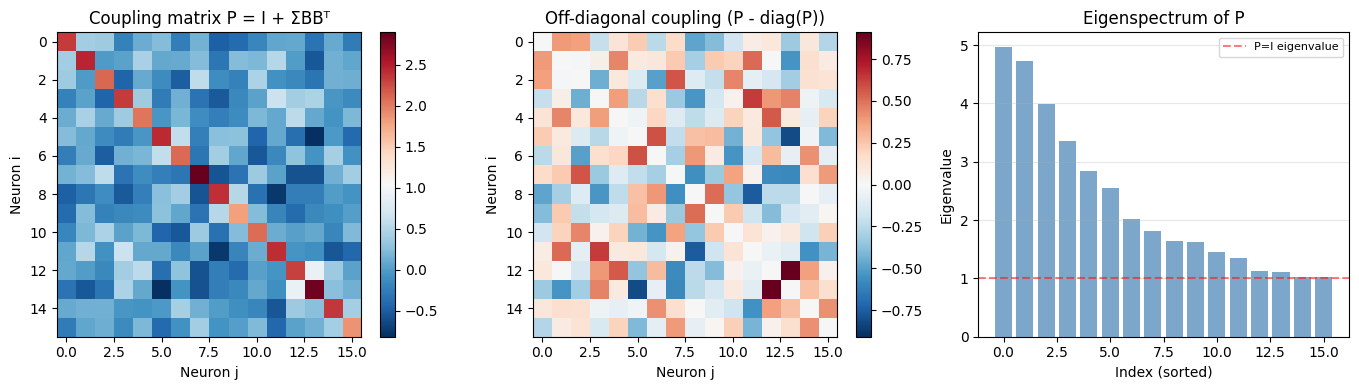

P condition number: 4.9
Off-diagonal energy: 62.6 (63.1% of total)


In [9]:
# Show the coupling matrix for the first layer of a freshly split model
torch.manual_seed(worst_idx)
demo_model = DecomposedSiren(LAYER_SIZES, omega_0=OMEGA_0).to(device)
demo_model.split_all(RANKS)

P = demo_model.decomposed_layers()[0].coupling_matrix().cpu().numpy()
P_offdiag = P - np.diag(np.diag(P))  # off-diagonal part only

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Full coupling matrix
ax = axes[0]
im = ax.imshow(P, cmap="RdBu_r", aspect="equal")
ax.set_title("Coupling matrix P = I + ΣBBᵀ")
ax.set_xlabel("Neuron j"); ax.set_ylabel("Neuron i")
plt.colorbar(im, ax=ax, fraction=0.046)

# Off-diagonal part (the interesting part)
ax = axes[1]
vmax = np.abs(P_offdiag).max()
im = ax.imshow(P_offdiag, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="equal")
ax.set_title("Off-diagonal coupling (P - diag(P))")
ax.set_xlabel("Neuron j"); ax.set_ylabel("Neuron i")
plt.colorbar(im, ax=ax, fraction=0.046)

# Eigenvalue spectrum of P
ax = axes[2]
eigvals = np.linalg.eigvalsh(P)
ax.bar(range(len(eigvals)), sorted(eigvals, reverse=True), color="steelblue", alpha=0.7)
ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="P=I eigenvalue")
ax.set_xlabel("Index (sorted)")
ax.set_ylabel("Eigenvalue")
ax.set_title("Eigenspectrum of P")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("siren_coupling_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"P condition number: {eigvals.max()/eigvals.min():.1f}")
print(f"Off-diagonal energy: {np.abs(P_offdiag).sum():.1f} "
      f"({100*np.abs(P_offdiag).sum()/np.abs(P).sum():.1f}% of total)")

del demo_model

## Summary

Both models start from the **same initialization** at every seed. The only difference is optimization geometry:

- **Baseline**: standard parameterization ($P = I$, no inter-neuron coupling). Neurons that initialize at similar frequencies stay trapped in degenerate configurations — their gradients are independent, so there is no force redistributing them across frequency space. This is the **frequency collapse** failure mode.

- **Baseline + Split**: the decomposition $W_{\text{eff}} = W + \sum_i B_i C_i$ introduces off-diagonal coupling $P = I + \sum_i B_i B_i^\top$. This mixes gradient information between neurons, providing an effective "repulsive interaction" that pushes degenerate neurons toward distinct frequencies. Periodic merge+resplit refreshes the coupling directions $B_i$, allowing the network to break new degeneracies as they form.

This is the same **dynamic gauge transformation** mechanism from the dead ReLU notebook, applied to a fundamentally different failure mode:

| | Dead ReLU | SIREN Frequency Collapse |
|---|---|---|
| **Failure** | Neuron permanently dead ($z_j < 0\ \forall x$) | Neurons locked at same frequency |
| **Root cause** | Zero gradient row ($G_{j,\cdot} = 0$) | Degenerate loss landscape (flat valleys) |
| **How $P$ helps** | Non-zero gradient through coupling | Gradient mixing breaks frequency symmetry |
| **Merge+resplit** | Refreshes coupling to revive more neurons | Refreshes coupling to resolve new degeneracies |

The coupling matrix doesn't change the function — it changes the *optimization trajectory* through parameter space, enabling escape from configurations that standard training cannot resolve.